## RQ 3 Observation 3.1

In [ ]:
# === Build dataset for Observation 3.1: Entry vs. Current (V9.3 aligned) ===
# - Canonical styles: Emu_Community, Emu_Custom, GMD, ThirdParty
# - "Both" label when Emu_Community and Emu_Custom co-exist
# - ≥14-day persistence for first & (strict) current
# - Snapshot-based current at cutoff (no ≥14-day filter) + <14d recency flag
# - Reads miner V9.3 outputs: *.emulator_timeline.json
# - Adds: full_name (owner.repo), merges MAIN's execution_environment (as-is),
#         merges all other MAIN columns EXCEPT those starting with 'api_' (case-insensitive),
#         and prefixes those other MAIN columns with 'main_' to avoid collisions.
# - Writes: ...\Observations\obs3_1_entry_vs_current.csv

from __future__ import annotations
import json
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple, Set
import pandas as pd

# ---- Paths ----
WORK_ROOT   = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT / "mineV9.3"

MAIN_CSV = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\5.0_Total_Repo.csv")

OBS_OUTPUT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations")
OBS_OUTPUT.mkdir(parents=True, exist_ok=True)

# ---- Settings ----
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"
PERSIST_DAYS = 14.0
CANONICAL_STYLES: Set[str] = {"Emu_Community", "Emu_Custom", "GMD", "ThirdParty"}

# ---- Helpers ----
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    # normalize +0000 -> +00:00
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, f"Bad CUTOFF_ISO: {CUTOFF_ISO}"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def normalize_styles(style_list: List[str]) -> Set[str]:
    return {s for s in (style_list or []) if s in CANONICAL_STYLES}

def label_from_set(s: Set[str]) -> str:
    if "Emu_Community" in s and "Emu_Custom" in s:
        return "Both"
    if "Emu_Community" in s:
        return "Community"
    if "Emu_Custom" in s:
        return "Custom"
    if "GMD" in s:
        return "GMD"
    if "ThirdParty" in s:
        return "ThirdParty"
    return "None"

def label_from_snapshot_set(s: Set[str]) -> str:
    # same priority order as label_from_set
    return label_from_set(s)

def read_repo_jsons(output_dir: Path) -> List[Path]:
    return sorted([p for p in output_dir.glob("*.emulator_timeline.json")])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Build contiguous episodes from timeline rows with non-empty canonical styles, capped at cutoff."""
    rows = [r for r in (timeline_rows or []) if r.get("styles")]
    rows.sort(key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc))

    episodes: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue

        styles_now = normalize_styles(list(r.get("styles") or []))
        if not styles_now:
            continue

        # end at the date of the next canonical row, else at cutoff
        end: Optional[datetime] = None
        for j in range(i + 1, len(rows)):
            nxt = rows[j]
            nxt_styles = normalize_styles(list(nxt.get("styles") or []))
            if nxt_styles:
                end = parse_iso(nxt.get("date"))
                break
        if end is None:
            end = cutoff_dt
        if end <= start:
            continue

        episodes.append({
            "start": start,
            "end": min(end, cutoff_dt),
            "styles": styles_now,
            "duration_days": max(0.0, days_between(start, min(end, cutoff_dt))),
        })
    return episodes

def first_active_label(episodes: List[Dict], min_days: float) -> Tuple[Optional[datetime], str, Set[str]]:
    """First episode meeting ≥ min_days."""
    eligible = [ep for ep in episodes if ep["duration_days"] >= min_days and ep["styles"]]
    if not eligible:
        return None, "None", set()
    earliest = min(eligible, key=lambda ep: ep["start"])
    return earliest["start"], label_from_set(earliest["styles"]), earliest["styles"]

def current_active_label_at_cutoff(episodes: List[Dict], cutoff_dt: datetime, min_days: float) -> Tuple[str, Set[str]]:
    """
    Strict (≥14d) current: episode covering the cutoff with duration ≥ min_days; else 'None'.
    Assumes final segment is capped at cutoff if active.
    """
    if not episodes:
        return "None", set()
    last = episodes[-1]
    if last["end"] < cutoff_dt:
        return "None", set()
    if last["duration_days"] >= min_days:
        return label_from_set(last["styles"]), last["styles"]
    return "None", set()

def _find_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """Case-insensitive column finder with common aliases."""
    lowmap = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lowmap:
            return lowmap[name.lower()]
    return None

# ---- Build OBS core from miner ----
records: List[Dict] = []

json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSON files found under: {OUTPUT_MINE}")

for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        rec = json.load(f)

    repo = rec.get("repo_name") or jf.stem
    timeline = rec.get("timeline") or []

    episodes = build_episodes(timeline, CUTOFF_DT)

    # First (≥14d)
    first_dt, first_label, first_styles = first_active_label(episodes, PERSIST_DAYS)

    # Strict current (≥14d)
    current_label_strict, current_styles_strict = current_active_label_at_cutoff(episodes, CUTOFF_DT, PERSIST_DAYS)

    # Snapshot-based current at cutoff (no ≥14d) — repo-wide union
    snap_def_raw  = rec.get("snapshot_as_of_cutoff_default") or []
    snap_all_raw  = rec.get("snapshot_as_of_cutoff_repo_wide") or []
    snap_def_norm_set  = normalize_styles(snap_def_raw)
    snap_all_norm_set  = normalize_styles(snap_all_raw)

    current_label_snapshot   = label_from_snapshot_set(snap_all_norm_set)
    current_styleset_snapshot = "+".join(sorted(snap_all_norm_set)) if snap_all_norm_set else ""

    # Recency flag: episode active at cutoff lasted <14d
    recent_lt14d = 0
    if episodes:
        last_ep = episodes[-1]
        if last_ep["end"] >= CUTOFF_DT and last_ep["duration_days"] < PERSIST_DAYS:
            recent_lt14d = 1

    full_name = (repo or "").replace("__", ".")

    out = {
        "repo_name": repo,
        "full_name": full_name,
        "cutoff_date": CUTOFF_ISO,

        # First adoption (≥14d)
        "first_date": first_dt.isoformat() if first_dt else "",
        "first_year": first_dt.year if first_dt else "",
        "first_label": first_label,
        "first_styleset": "+".join(sorted(first_styles)) if first_styles else "",

        # Current at cutoff — strict vs snapshot
        "current_label_strict": current_label_strict,                                        # ≥14d
        "current_styleset_strict": "+".join(sorted(current_styles_strict)) if current_styles_strict else "",
        "current_label_snapshot": current_label_snapshot,                                    # no ≥14d
        "current_styleset_snapshot": current_styleset_snapshot,
        "current_recent_lt14d": recent_lt14d,                                               # 1 if active <14d at cutoff

        # Diagnostics / parity checks
        "snapshot_default_norm": "+".join(sorted(snap_def_norm_set)) if snap_def_norm_set else "",
        "snapshot_repo_wide_norm": "+".join(sorted(snap_all_norm_set)) if snap_all_norm_set else "",
        "qa_issue": rec.get("qa_issue", ""),
    }
    records.append(out)

df = pd.DataFrame.from_records(records).sort_values(["first_date", "repo_name"], na_position="last")

# ---- Merge MAIN: include 'execution_environment' as-is; exclude api_*; prefix the rest with main_ ----
if MAIN_CSV.exists():
    df_main = pd.read_csv(MAIN_CSV, dtype=str, encoding="utf-8", keep_default_na=False)

    col_full = _find_col(df_main, ["full_name", "Full_name", "repo_full_name"])
    col_exec = _find_col(df_main, ["execution_environment", "Execution_Environment"])

    if col_full:
        # normalize join keys
        df["_key"] = df["full_name"].astype(str).str.lower().str.strip()
        df_main["_key"] = df_main[col_full].astype(str).str.lower().str.strip()

        # 1) execution_environment as-is (if present)
        if col_exec:
            df_exec = df_main[["_key", col_exec]].copy()
            df_exec.rename(columns={col_exec: "execution_environment"}, inplace=True)
            df = df.merge(df_exec, on="_key", how="left")
        else:
            df["execution_environment"] = ""

        # 2) other MAIN columns (exclude join col, exec col, helper, and any api_* columns)
        main_cols = []
        for c in df_main.columns:
            cl = c.lower()
            if c in {"_key", col_full}:
                continue
            if col_exec and c == col_exec:
                continue
            if cl.startswith("api_"):
                continue
            main_cols.append(c)

        if main_cols:
            df_other = df_main[["_key"] + main_cols].copy()
            df_other.rename(columns={c: f"main_{c}" for c in main_cols}, inplace=True)
            df = df.merge(df_other, on="_key", how="left")

        # drop helper
        df.drop(columns=["_key"], inplace=True, errors="ignore")
    else:
        # MAIN lacks a usable full_name join key
        df["execution_environment"] = ""
else:
    df["execution_environment"] = ""

# ---- Column order: repo_name, full_name, execution_environment, then the rest ----
cols = list(df.columns)
for required in ["repo_name", "full_name", "execution_environment"]:
    if required not in cols:
        cols.insert(0, required)

# place full_name after repo_name
if "repo_name" in cols and "full_name" in cols:
    cols.remove("full_name")
    cols.insert(cols.index("repo_name") + 1, "full_name")

# place execution_environment after full_name
if "execution_environment" in cols:
    cols.remove("execution_environment")
    insert_at = cols.index("full_name") + 1 if "full_name" in cols else 1
    cols.insert(insert_at, "execution_environment")

df = df[cols]

# ---- Save ----
out_csv = OBS_OUTPUT / "obs3_1_entry_vs_current.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[ok] Wrote dataset: {out_csv}")

# Optional quick peek
try:
    show_cols = [
        "repo_name","full_name","execution_environment",
        "first_year","first_label",
        "current_label_strict","current_label_snapshot",
        "current_recent_lt14d",
        "first_date","current_styleset_strict","current_styleset_snapshot",
        "snapshot_repo_wide_norm"
    ]
    show_cols += [c for c in df.columns if c.startswith("main_")][:3]
    print(df[show_cols].head(20).to_string(index=False))
except Exception:
    pass


[ok] Wrote dataset: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_1_entry_vs_current.csv
                                repo_name                                full_name                execution_environment first_year first_label current_label_strict current_label_snapshot  current_recent_lt14d                first_date current_styleset_strict    current_styleset_snapshot      snapshot_repo_wide_norm                                               main_html_url main_native_instru_test main_flutter_instru_test
                        maxistar__TextPad                         maxistar.TextPad                          Real Device                   None                 None                   None                     0                                                                                                                                     https://github.com/maxistar/TextPad                       6                        0
                  

## RQ3 - F2

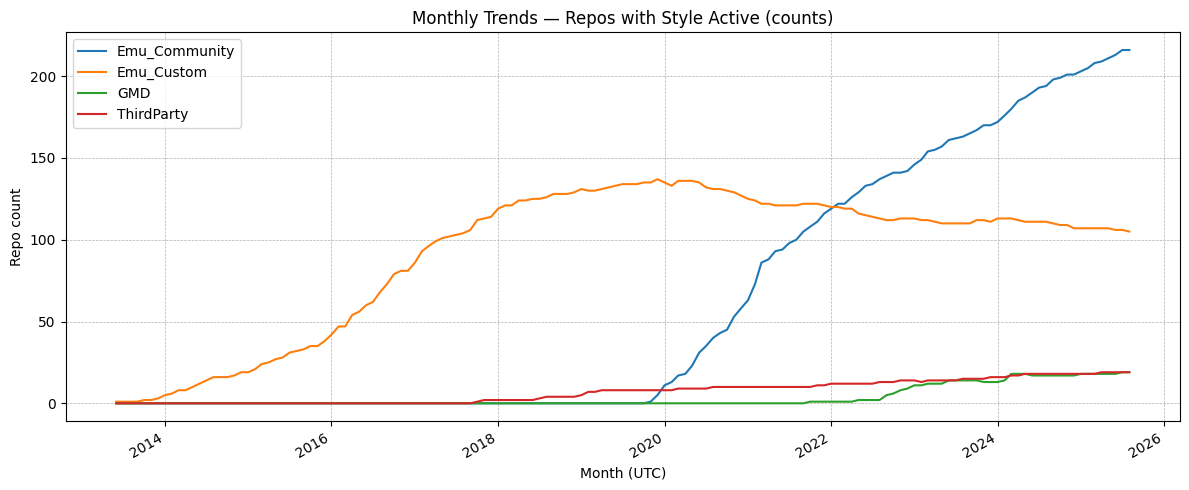

In [15]:
# === Observation 3.2 — Monthly Trends (single plot, no files) ===
# - Reads miner V9.3 JSONs (*.emulator_timeline.json)
# - Applies ≥14-day persistence
# - Counts per style per month; multi-style months count to each style
# - Plots all four styles on ONE matplotlib chart (no saving)

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd
import matplotlib.pyplot as plt  # matplotlib only

# -------- Paths --------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"  # folder with *.emulator_timeline.json

# -------- Settings --------
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"    # must match miner
PERSIST_DAYS = 14.0
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")

# -------- Helpers --------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+", "-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(output_dir: Path) -> List[Path]:
    return sorted([p for p in output_dir.glob("*.emulator_timeline.json") if p.name not in {"index_summary.json"}])

# ---- TZ-safe month helpers (no Period conversion) ----
def month_start_key(dt: datetime) -> pd.Timestamp:
    """Return a naive pd.Timestamp at the UTC month start for dt."""
    dt_utc = dt.astimezone(timezone.utc)
    return pd.Timestamp(year=dt_utc.year, month=dt_utc.month, day=1)

def next_month(ts: pd.Timestamp) -> pd.Timestamp:
    y, m = ts.year, ts.month
    if m == 12:
        return pd.Timestamp(year=y + 1, month=1, day=1)
    return pd.Timestamp(year=y, month=m + 1, day=1)

def month_range(start: datetime, end: datetime) -> List[pd.Timestamp]:
    """List of UTC month starts covering [start, end)."""
    if end <= start:
        return []
    months: List[pd.Timestamp] = []
    cur = month_start_key(start)
    end_ms = month_start_key(end)
    # include cur while end spills into (or beyond) that month
    while cur < end_ms or (cur == end_ms and end > end.replace(day=1, hour=0, minute=0, second=0, microsecond=0, tzinfo=end.tzinfo)):
        months.append(cur)
        cur = next_month(cur)
    return months

# -------- Build episodes from miner timeline --------
def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_set = set(r.get("styles") or [])
        nxt_date = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = nxt_date or cutoff_dt
        end = min(end, cutoff_dt)
        if end <= start:
            continue
        eps.append({
            "start": start, "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def filter_active_episodes(episodes: List[Dict], min_days: float) -> List[Dict]:
    """Keep episodes with duration >= min_days and at least one tracked style."""
    out = []
    for ep in episodes:
        if ep["duration_days"] < min_days:
            continue
        sty = set(s for s in ep["styles"] if s in STYLES)
        if not sty:
            continue
        ep = dict(ep)
        ep["styles"] = sty
        out.append(ep)
    return out

# -------- Load miner outputs --------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSON files found under: {OUTPUT_MINE}")

repo_eps: Dict[str, List[Dict]] = {}
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps_all = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    eps_active = filter_active_episodes(eps_all, PERSIST_DAYS)
    repo_eps[repo] = eps_active

# -------- Build monthly counts per style --------
rows_monthly: List[Dict] = []
global_months: Set[pd.Timestamp] = set()

for repo, eps in repo_eps.items():
    if eps:
        start_min = min(ep["start"] for ep in eps)
        end_max = max(ep["end"] for ep in eps)
        months = month_range(start_min, end_max)
    else:
        months = []
    for m in months:
        global_months.add(m)
        m_start = m.tz_localize("UTC")
        m_end = next_month(m).tz_localize("UTC")
        # union of styles active at any time overlapping this month
        act_sets = []
        for ep in eps:
            if ep["start"] < m_end and ep["end"] > m_start:
                act_sets.append(ep["styles"])
        style_set = set().union(*act_sets) if act_sets else set()
        rows_monthly.append({
            "repo_name": repo,
            "month": m,  # naive Timestamp (UTC month start)
            "Emu_Community": 1 if "Emu_Community" in style_set else 0,
            "Emu_Custom":    1 if "Emu_Custom"    in style_set else 0,
            "GMD":           1 if "GMD"           in style_set else 0,
            "ThirdParty":    1 if "ThirdParty"    in style_set else 0,
        })

dfm = pd.DataFrame(rows_monthly)
if dfm.empty:
    raise RuntimeError("No monthly rows produced. Check mined data and persistence settings.")

monthly_counts = (
    dfm.groupby("month")[["Emu_Community","Emu_Custom","GMD","ThirdParty"]]
    .sum()
    .reset_index()
    .sort_values("month")
)

# -------- Single plot with all styles --------
fig = plt.figure(figsize=(12, 5))
plt.plot(monthly_counts["month"], monthly_counts["Emu_Community"], marker="", label="Emu_Community")
plt.plot(monthly_counts["month"], monthly_counts["Emu_Custom"],    marker="", label="Emu_Custom")
plt.plot(monthly_counts["month"], monthly_counts["GMD"],           marker="", label="GMD")
plt.plot(monthly_counts["month"], monthly_counts["ThirdParty"],    marker="", label="ThirdParty")

plt.title("Monthly Trends — Repos with Style Active (counts)")
plt.xlabel("Month (UTC)")
plt.ylabel("Repo count")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


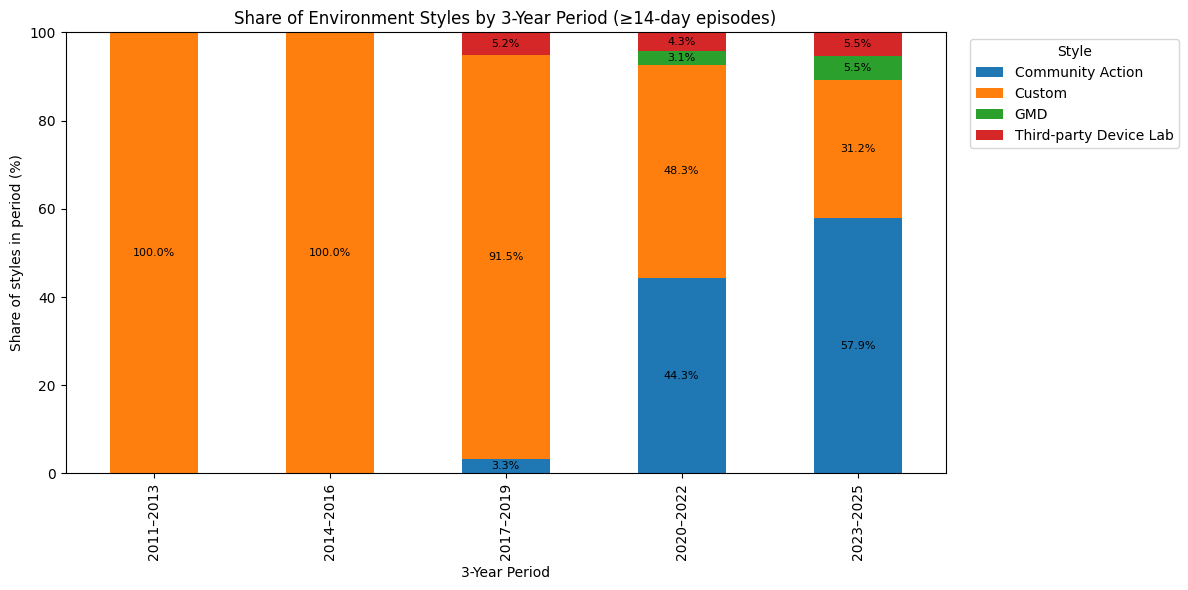

In [20]:
# === Stacked Bar Plot with On-Bar Percentage Labels (3-year buckets, tz-safe) ===
# • Styles shown as: Community Action, Custom, GMD, Third-party Device Lab
# • Buckets: 2008–2010, 2011–2013, …, 2023–2025
# • ≥14-day persistence; multi-label counting; tz-safe month handling

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"

# ---------- Settings ----------
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"
PERSIST_DAYS = 14.0
# Miner keys (do not change):
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
# Display names for the plot:
DISPLAY_MAP = {
    "Emu_Community": "Community Action",
    "Emu_Custom": "Custom",
    "GMD": "GMD",
    "ThirdParty": "Third-party Device Lab",
}
DISPLAY_ORDER = [DISPLAY_MAP[s] for s in STYLES]

YEAR_START, YEAR_END = 2008, 2025
BUCKET_SIZE = 3  # years per bucket

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    """Parse ISO-ish string to timezone-aware UTC datetime."""
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

# --- tz-safe month utilities (no Period conversions) ---
def month_start_key(dt: datetime) -> pd.Timestamp:
    """UTC month start (naive pandas Timestamp used as month key)."""
    u = dt.astimezone(timezone.utc)
    return pd.Timestamp(u.year, u.month, 1)

def next_month(ts: pd.Timestamp) -> pd.Timestamp:
    y, m = ts.year, ts.month
    return pd.Timestamp(y + (1 if m == 12 else 0), 1 if m == 12 else m + 1, 1)

def month_range(start: datetime, end: datetime) -> List[pd.Timestamp]:
    """List of UTC month starts covering [start, end)."""
    if end <= start:
        return []
    months: List[pd.Timestamp] = []
    cur = month_start_key(start)
    end_ms = month_start_key(end)
    while cur < end_ms or (cur == end_ms and end > end.replace(day=1, hour=0, minute=0, second=0, microsecond=0, tzinfo=end.tzinfo)):
        months.append(cur)
        cur = next_month(cur)
    return months

def bucket_label(year: int) -> str:
    """Map a year to its 3-year bucket label, e.g., 2008→'2008–2010'."""
    k = (year - YEAR_START) // BUCKET_SIZE
    y0 = YEAR_START + k * BUCKET_SIZE
    y1 = min(y0 + BUCKET_SIZE - 1, YEAR_END)
    return f"{y0}–{y1}"

# ---------- Build episodes from miner timeline ----------
CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Contiguous active-style episodes from non-empty timeline rows, capped at cutoff."""
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        # keep only canonical V9.3 styles
        styles_set = set(s for s in (r.get("styles") or []) if s in STYLES)

        nxt_date = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(nxt_date or cutoff_dt, cutoff_dt)
        if end <= start:
            continue

        eps.append({
            "start": start, "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def filter_active(eps: List[Dict], min_days: float) -> List[Dict]:
    """Keep episodes that persist ≥ min_days and include at least one tracked style."""
    out = []
    for ep in eps:
        if ep["duration_days"] < min_days:
            continue
        sty = set(s for s in ep["styles"] if s in STYLES)
        if not sty:
            continue
        ep = dict(ep)
        ep["styles"] = sty
        out.append(ep)
    return out

# ---------- Build monthly activity (multi-label; gaps excluded) ----------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

rows = []
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps = filter_active(build_episodes(data.get("timeline") or [], CUTOFF_DT), PERSIST_DAYS)
    if not eps:
        continue
    start_min = min(ep["start"] for ep in eps)
    end_max = max(ep["end"] for ep in eps)
    months = month_range(start_min, end_max)
    for m in months:
        # m is naive (UTC month start as key); localize to UTC for overlap check
        m_start = m.tz_localize("UTC")
        m_end = next_month(m).tz_localize("UTC")
        styles_active: Set[str] = set()
        for ep in eps:
            if ep["start"] < m_end and ep["end"] > m_start:
                styles_active |= ep["styles"]
        if styles_active:
            rows.append({
                "repo_name": repo,
                "month": m,
                **{s: (1 if s in styles_active else 0) for s in STYLES}
            })

dfm = pd.DataFrame(rows).sort_values(["month","repo_name"]).reset_index(drop=True)
if dfm.empty:
    raise RuntimeError("No data to plot after applying ≥14-day rule. Check miner outputs and CUTOFF_ISO.")

# ---------- Aggregate to 3-year buckets ----------
dfm["bucket"] = dfm["month"].dt.year.map(bucket_label)

# Count repos per style per bucket (repo counted once per style if it appears in ANY month of the bucket)
style_bucket_counts = (
    dfm.groupby(["bucket","repo_name"])[list(STYLES)]
       .max()
       .reset_index()
       .groupby("bucket")[list(STYLES)]
       .sum()
       .sort_index()
)

# Convert to shares that sum to 100% per bucket (style mix)
tot_mentions = style_bucket_counts.sum(axis=1).replace(0, pd.NA)
style_bucket_shares = (style_bucket_counts.T / tot_mentions).T.fillna(0.0) * 100.0

# --- Rename columns to display names and enforce display order ---
style_bucket_shares = style_bucket_shares.rename(columns=DISPLAY_MAP)
# Ensure consistent column order (only keep those present)
present_cols = [c for c in DISPLAY_ORDER if c in style_bucket_shares.columns]
style_bucket_shares = style_bucket_shares[present_cols]

# ---------- Plot: Stacked bars with percentage labels ----------
ax = style_bucket_shares.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Share of Environment Styles by 3-Year Period (≥14-day episodes)")
ax.set_xlabel("3-Year Period")
ax.set_ylabel("Share of styles in period (%)")
ax.set_ylim(0, 100)
ax.legend(title="Style", bbox_to_anchor=(1.02, 1), loc="upper left")

# On-bar % labels
buckets = style_bucket_shares.index.tolist()
cols = style_bucket_shares.columns.tolist()
for i, bucket in enumerate(buckets):
    cum = 0.0
    for sty in cols:
        val = float(style_bucket_shares.loc[bucket, sty])
        if val <= 0.0:
            continue
        y_center = cum + val / 2.0
        ax.text(i, y_center, f"{val:.1f}%", ha="center", va="center", fontsize=8)
        cum += val

plt.tight_layout()
plt.show()


In [18]:
# === RQ3 Opening Stats: Basic Episode Facts & ≥14-day Exclusions (V9.3-aligned) ===
# - Totals across all repos
# - Episodes with ≥1 tracked style (Emu_Community / Emu_Custom / GMD / ThirdParty)
# - Episodes excluded by the ≥14-day rule and affected repos

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd

# ---------- Paths ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.3"   # <-- V9.3

# ---------- Settings ----------
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"
PERSIST_MIN  = 14.0  # episodes shorter than this are excluded
STYLES       = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")  # canonical set

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Build contiguous episodes from non-empty timeline rows; each episode has [start,end), styles, duration_days."""
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles") is not None),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        # Keep only tracked (canonical) styles
        styles_set = set(s for s in (r.get("styles") or []) if s in STYLES)

        nxt = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(nxt or cutoff_dt, cutoff_dt)
        if end <= start:
            continue

        eps.append({
            "start": start,
            "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

# ---------- Load all repos & assemble episode table ----------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

episode_rows = []
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    for ep in eps:
        episode_rows.append({
            "repo_name": repo,
            "start": ep["start"],
            "end": ep["end"],
            "duration_days": ep["duration_days"],
            "has_tracked_style": 1 if (ep["styles"] and len(ep["styles"]) > 0) else 0,
            # style flags (multi-label): episode can count toward multiple styles
            **{s: (1 if (ep["styles"] and s in ep["styles"]) else 0) for s in STYLES}
        })

episodes_df = pd.DataFrame(episode_rows).sort_values(["start","repo_name"]).reset_index(drop=True)

if episodes_df.empty:
    print("No episodes detected across repos. Check miner outputs.")
else:
    # ---------- Basic totals ----------
    total_eps = len(episodes_df)
    repos_with_any_eps = episodes_df["repo_name"].nunique()

    eps_with_style = episodes_df[episodes_df["has_tracked_style"] == 1]
    total_eps_with_style = len(eps_with_style)
    repos_with_style_eps = eps_with_style["repo_name"].nunique()

    # ---------- Exclusions under ≥14-day rule (only episodes that have tracked styles) ----------
    excluded = eps_with_style[eps_with_style["duration_days"] < PERSIST_MIN]
    excluded_eps = len(excluded)
    repos_with_excluded = excluded["repo_name"].nunique()

    # ---------- Print summary ----------
    print("=== RQ3 Opening Facts (Episodes & ≥14-day Exclusions) ===")
    print(f"Total change episodes (all kinds): {total_eps}  across {repos_with_any_eps} repos")
    print(f"Episodes with ≥0 tracked style:    {total_eps_with_style}  across {repos_with_style_eps} repos")
    print(f"Excluded by ≥14-day rule:         {excluded_eps}  episodes  across {repos_with_excluded} repos")

    if total_eps_with_style > 0:
        print("\nDuration stats for episodes WITH tracked styles (days):")
        print(eps_with_style["duration_days"].describe().round(2))

    if excluded_eps > 0:
        print("\nDuration stats for EXCLUDED episodes (duration < 14 days):")
        print(excluded["duration_days"].describe().round(2))

        # Per-style counts among excluded (multi-label)
        for s in STYLES:
            if s not in excluded.columns:
                excluded[s] = 0
        print("\nExcluded episodes per style (multi-label counts):")
        print(excluded[list(STYLES)].sum().astype(int))


=== RQ3 Opening Facts (Episodes & ≥14-day Exclusions) ===
Total change episodes (all kinds): 516  across 348 repos
Episodes with ≥0 tracked style:    516  across 348 repos
Excluded by ≥14-day rule:         54  episodes  across 28 repos

Duration stats for episodes WITH tracked styles (days):
count     516.00
mean     1369.55
std      1148.19
min         0.00
25%       412.89
50%      1202.71
75%      1989.95
max      4243.05
Name: duration_days, dtype: float64

Duration stats for EXCLUDED episodes (duration < 14 days):
count    54.00
mean      1.87
std       3.34
min       0.00
25%       0.04
50%       0.31
75%       1.90
max      13.73
Name: duration_days, dtype: float64

Excluded episodes per style (multi-label counts):
Emu_Community    29
Emu_Custom       19
GMD              10
ThirdParty        7
dtype: int64
